In [6]:
import numpy as np
import pandas as pd
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from typing import Tuple
#matplotlib inline
from matplotlib import pyplot as plt


#@title **Location** of the dataset
path =  "DataLink/TFN_EXP/"

df = pd.read_csv(path+'all_arm_summaries.csv')    #HomeCredit training dataset


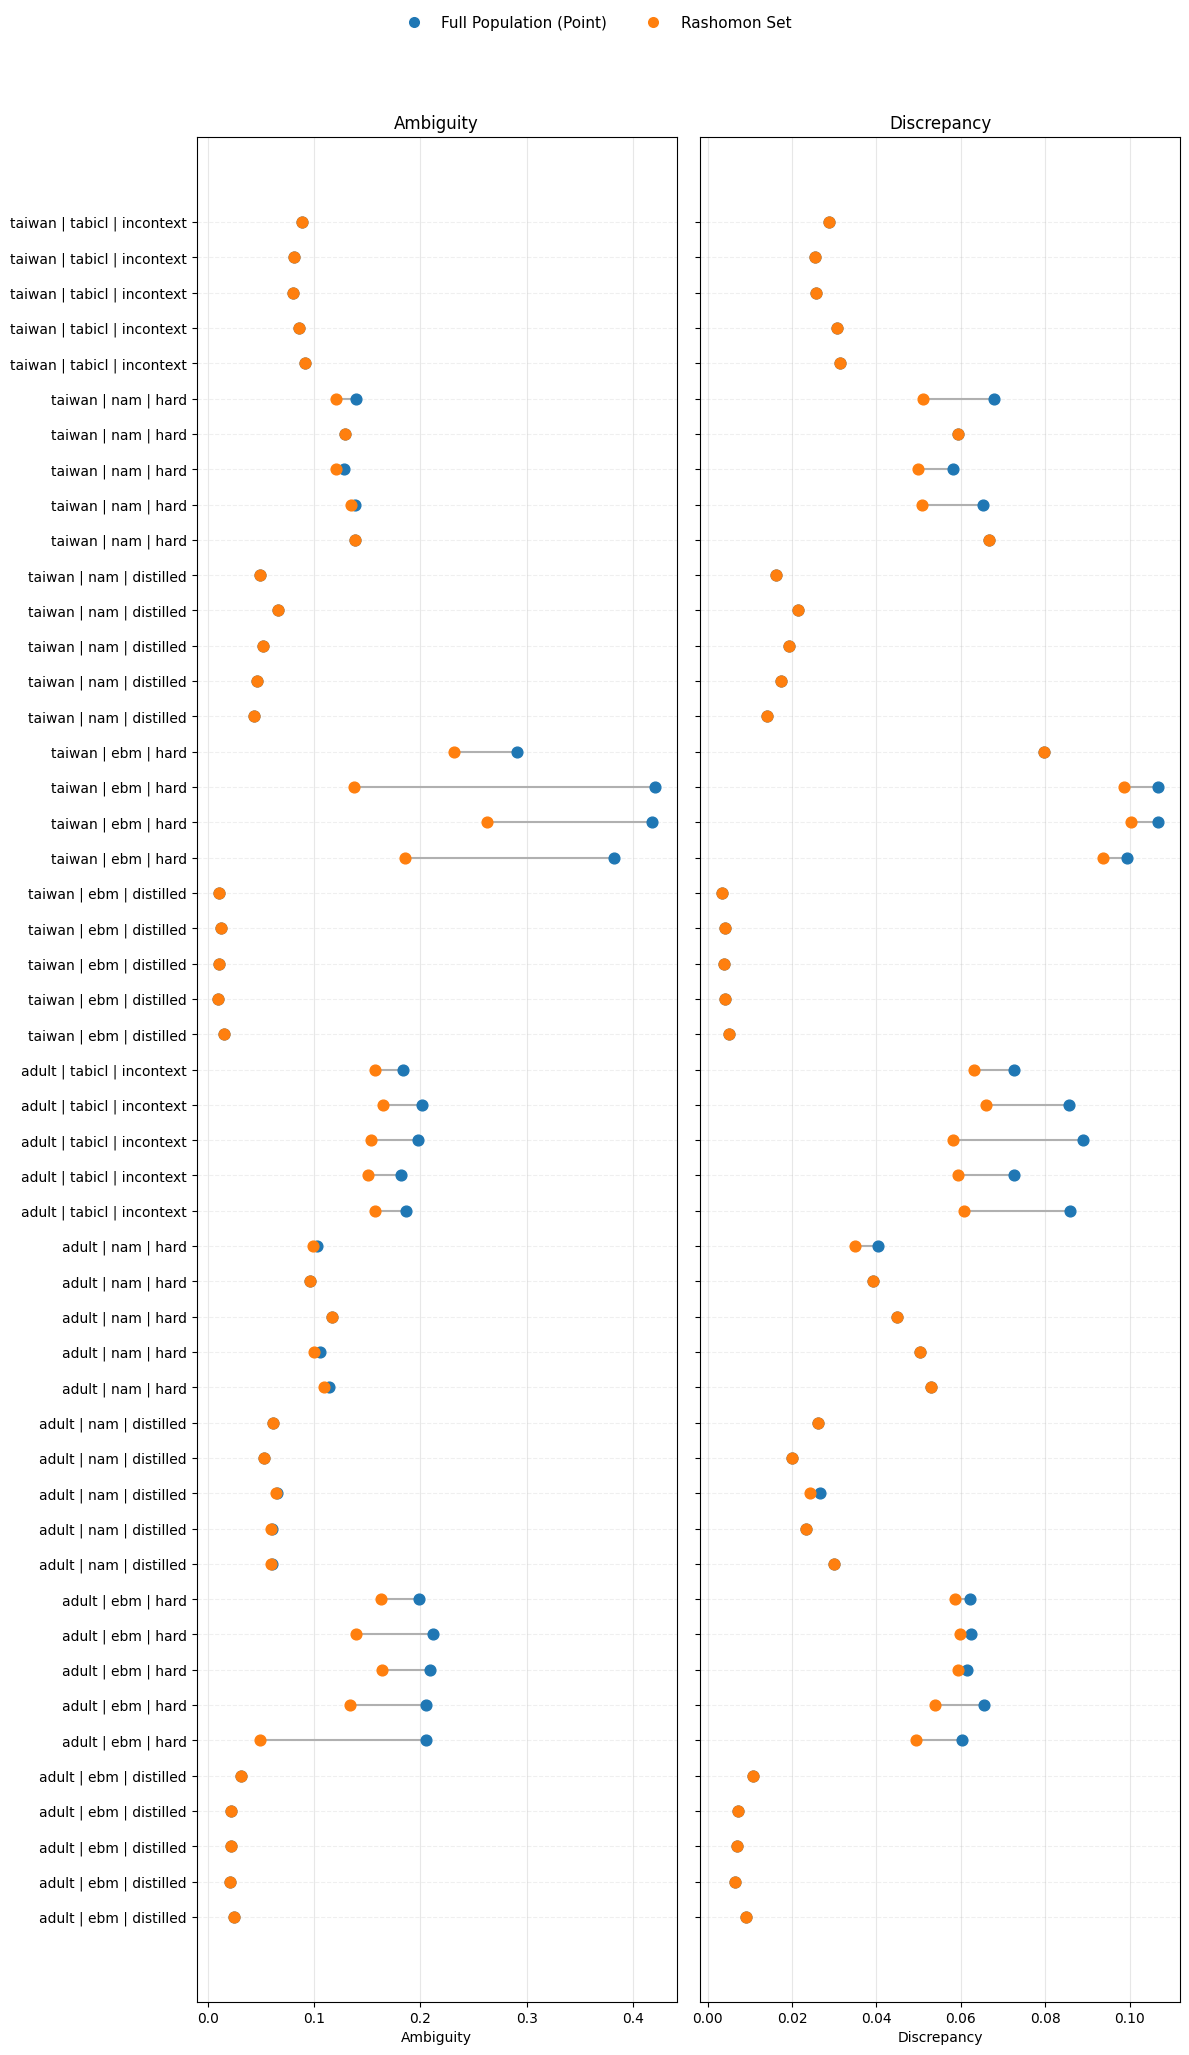

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# Load data
# df = pd.read_csv("your_results.csv")

# Keep only rows with the required values
plot_df = df.dropna(
    subset=[
        "dataset",
        "model",
        "arm",
        "ambiguity_point",
        "rashomon_ambiguity",
        "discrepancy_point",
        "rashomon_discrepancy",
    ]
).copy()

# Identifier for each experimental condition
plot_df["condition"] = (
    plot_df["dataset"].astype(str)
    + " | "
    + plot_df["model"].astype(str)
    + " | "
    + plot_df["arm"].astype(str)
)

# Sort for a stable presentation
plot_df = plot_df.sort_values(["dataset", "model", "arm"]).reset_index(drop=True)

fig, axes = plt.subplots(
    1, 2,
    figsize=(12, max(5, 0.4 * len(plot_df))), # Slightly adjusted for legend space
    sharey=True
)

# Visual configuration
color_full = "#1f77b4"      # Blue
color_rashomon = "#ff7f0e"  # Orange
line_color = "#b0b0b0"      # Light Gray

# ---------------------------------------------------------
# Ambiguity
# ---------------------------------------------------------
ax = axes[0]

for i, row in plot_df.iterrows():
    # Draw the connecting line (zorder=1 to push it behind the dots)
    ax.plot(
        [row["ambiguity_point"], row["rashomon_ambiguity"]],
        [i, i],
        color=line_color,
        linewidth=1.5,
        zorder=1
    )
    # Draw the individual points (zorder=2 to sit on top of the line)
    ax.scatter(row["ambiguity_point"], i, color=color_full, s=60, zorder=2)
    ax.scatter(row["rashomon_ambiguity"], i, color=color_rashomon, s=60, zorder=2)

ax.set_yticks(np.arange(len(plot_df)))
ax.set_yticklabels(plot_df["condition"])
ax.set_xlabel("Ambiguity")
ax.set_title("Ambiguity")
ax.grid(axis="x", alpha=0.3)
ax.grid(axis="y", linestyle="--", alpha=0.2) # Horizontal lines to guide the eye

# ---------------------------------------------------------
# Discrepancy
# ---------------------------------------------------------
ax = axes[1]

for i, row in plot_df.iterrows():
    # Draw the connecting line
    ax.plot(
        [row["discrepancy_point"], row["rashomon_discrepancy"]],
        [i, i],
        color=line_color,
        linewidth=1.5,
        zorder=1
    )
    # Draw the individual points
    ax.scatter(row["discrepancy_point"], i, color=color_full, s=60, zorder=2)
    ax.scatter(row["rashomon_discrepancy"], i, color=color_rashomon, s=60, zorder=2)

ax.set_xlabel("Discrepancy")
ax.set_title("Discrepancy")
ax.grid(axis="x", alpha=0.3)
ax.grid(axis="y", linestyle="--", alpha=0.2)

# ---------------------------------------------------------
# Legend
# ---------------------------------------------------------
# Create custom legend entries
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Full Population (Point)', 
           markerfacecolor=color_full, markersize=9),
    Line2D([0], [0], marker='o', color='w', label='Rashomon Set', 
           markerfacecolor=color_rashomon, markersize=9)
]

# Place legend spanning both subplots at the top
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 1.05), 
           ncol=2, frameon=False, fontsize=11)

plt.tight_layout()
plt.savefig(
    "full_vs_rashomon_multiplicity.pdf",
    bbox_inches="tight"
)
plt.savefig(
    "full_vs_rashomon_multiplicity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

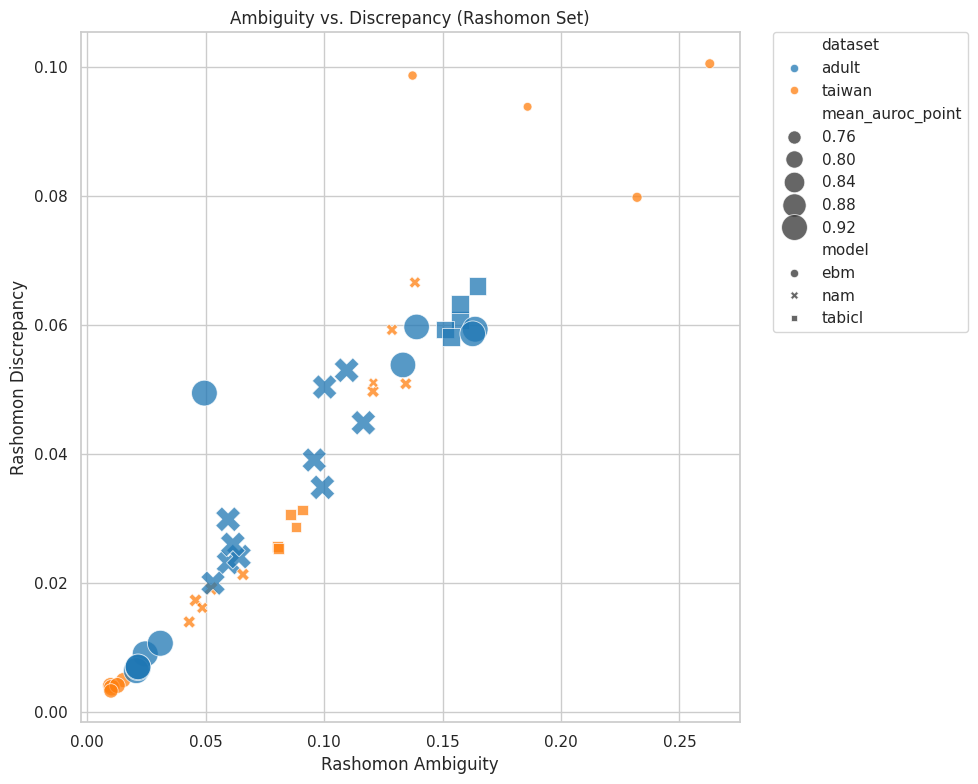

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
# df = pd.read_csv("your_results.csv")

# Use exact column names from your dataset
x_col = "rashomon_ambiguity"
y_col = "rashomon_discrepancy"
size_col = "mean_auroc_point"  # or "auroc_mean"

# Clean data for the plot, ensuring all required columns exist
plot_df = df.dropna(
    subset=[x_col, y_col, "model", "dataset", size_col]
).copy()

# Set up the figure
plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid")

# Create the scatter plot
ax = sns.scatterplot(
    data=plot_df,
    x=x_col,
    y=y_col,
    style="model",       # Marker shapes mapped to the model
    size=size_col,       # Marker size mapped to AUROC
    hue="dataset",       # Marker color mapped to dataset
    sizes=(40, 350),     # Minimum and maximum point sizes
    alpha=0.75,          # Transparency to handle overlapping points
    palette="tab10"
)

# Formatting
plt.xlabel("Rashomon Ambiguity")
plt.ylabel("Rashomon Discrepancy")
plt.title("Ambiguity vs. Discrepancy (Rashomon Set)")

# Move legend outside the plot so it doesn't cover data points
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout()
plt.savefig("ambiguity_vs_discrepancy.pdf", bbox_inches="tight")
plt.savefig("ambiguity_vs_discrepancy.png", dpi=300, bbox_inches="tight")

plt.show()

In [18]:
import pandas as pd

# Filter out tabicl to compare just the interpretable models' arms
students_df = df[df["model"].isin(["ebm", "nam"])].copy()

# Pivot the data to align 'hard' and 'distilled' metrics side-by-side
pivot_df = students_df.pivot_table(
    index=["dataset", "model"],
    columns="arm",
    values=["mean_auroc_point", "rashomon_ambiguity", "rashomon_discrepancy"]
)

# Calculate the Delta (Distilled - Hard)
# Positive AUROC delta = Distilled is better
# Negative Ambiguity/Discrepancy delta = Distilled is better (lower multiplicity)
for metric in ["mean_auroc_point", "rashomon_ambiguity", "rashomon_discrepancy"]:
    pivot_df[(metric, "delta_(distilled_minus_hard)")] = (
        pivot_df[(metric, "distilled")] - pivot_df[(metric, "hard")]
    )

# Flatten columns for readability and sort by dataset and model
pivot_df.columns = ['_'.join(col).strip() for col in pivot_df.columns.values]
pivot_df = pivot_df.reset_index()

pivot_df[["dataset", "model", 
                "mean_auroc_point_delta_(distilled_minus_hard)", 
                "rashomon_ambiguity_delta_(distilled_minus_hard)"]]

,dataset,model,mean_auroc_point_delta_(distilled_minus_hard),rashomon_ambiguity_delta_(distilled_minus_hard)
0,adult,ebm,0.003562,-0.105863
1,adult,nam,0.000248,-0.044737
2,taiwan,ebm,0.050321,-0.192917
3,taiwan,nam,0.009158,-0.077524


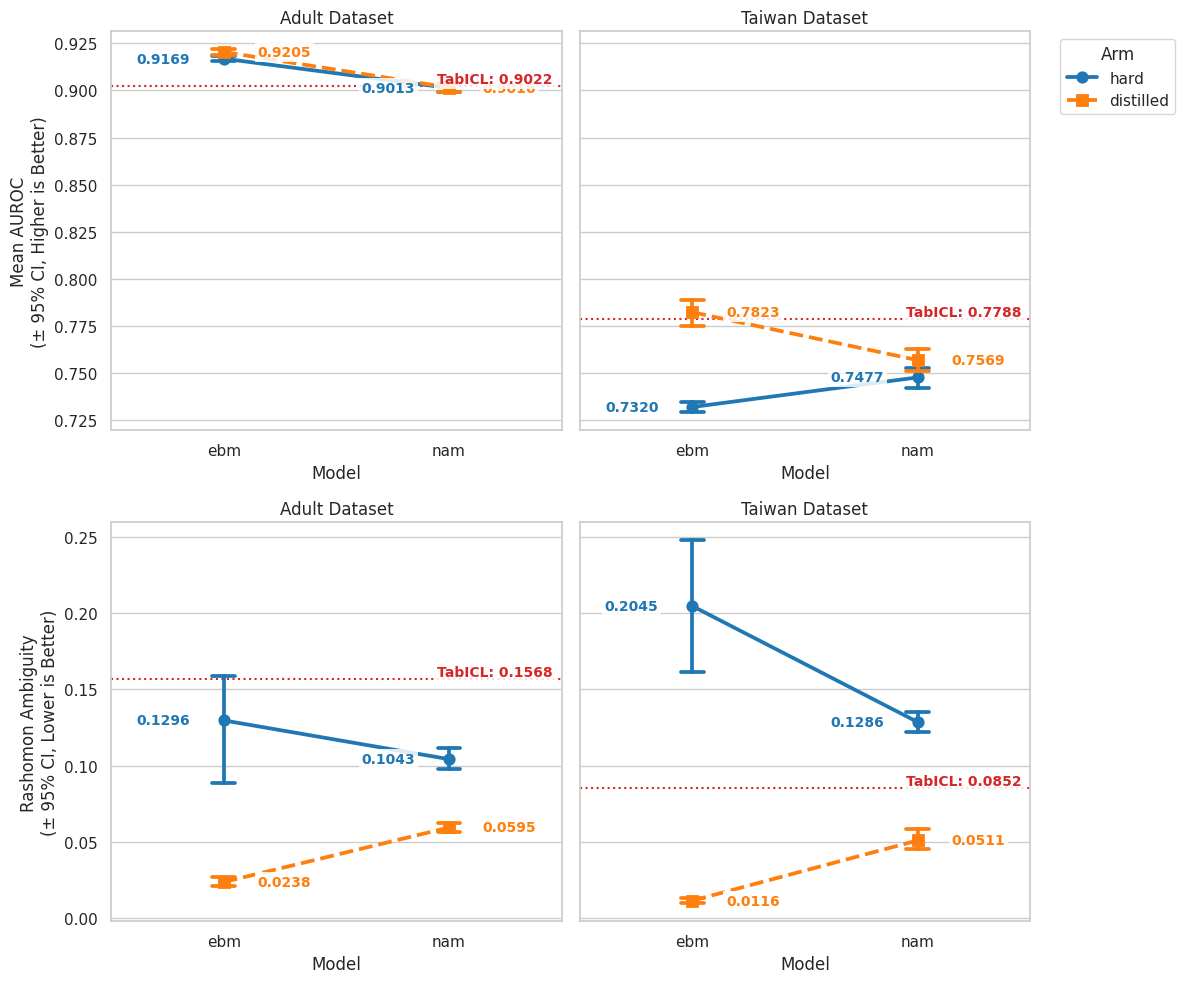

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define metrics to plot and explicitly state the variance (95% CI)
metrics = {
    "mean_auroc_point": "Mean AUROC\n(± 95% CI, Higher is Better)",
    "rashomon_ambiguity": "Rashomon Ambiguity\n(± 95% CI, Lower is Better)"
}

datasets = df["dataset"].unique()

fig, axes = plt.subplots(len(metrics), len(datasets), figsize=(12, 10), sharey="row")

for i, (metric, ylabel) in enumerate(metrics.items()):
    for j, dataset in enumerate(datasets):
        ax = axes[i, j]
        
        # Subset for current dataset
        ds_data = df[df["dataset"] == dataset]
        
        # Extract TabICL baseline for reference line
        tabicl_val = ds_data[ds_data["model"] == "tabicl"][metric].mean()
        
        # Filter out TabICL for the main categorical plot
        student_data = ds_data[ds_data["model"] != "tabicl"]
        
        # Plot EBM and NAM comparing Hard vs Distilled
        sns.pointplot(
            data=student_data,
            x="model",
            y=metric,
            hue="arm",
            dodge=False,
            markers=["o", "s"],
            linestyles=["-", "--"],
            palette={"hard": "#1f77b4", "distilled": "#ff7f0e"},
            errorbar=('ci', 95),  
            capsize=0.1,          
            ax=ax,
            zorder=2
        )
        
        # --- Add exact values to the points ---
        model_order = student_data["model"].unique()
        model_to_x = {model: idx for idx, model in enumerate(model_order)}
        
        agg_data = student_data.groupby(["model", "arm"])[metric].mean().reset_index()
        
        for _, row in agg_data.iterrows():
            model = row["model"]
            arm = row["arm"]
            val = row[metric]
            
            x_pos = model_to_x[model]
            x_offset = -0.15 if arm == "hard" else 0.15
            ha = 'right' if arm == "hard" else 'left'
            color = "#1f77b4" if arm == "hard" else "#ff7f0e"
            
            ax.text(
                x=x_pos + x_offset, 
                y=val, 
                s=f"{val:.4f}",
                color=color,
                va='center', 
                ha=ha,
                fontweight='bold',
                fontsize=10,
                zorder=3,
                bbox=dict(facecolor='white', alpha=0.85, edgecolor='none', pad=2) 
            )
        # ---------------------------------------------------------
        
        # --- NEW: Add TabICL reference line and text directly on plot ---
        if pd.notna(tabicl_val):
            # Draw the line without a label so it doesn't go to the legend
            ax.axhline(tabicl_val, color="#d62728", linestyle=":", zorder=1)
            
            # Place the text directly on the plot, resting on the line
            ax.text(
                x=0.98,               # 98% of the way to the right side of the plot
                y=tabicl_val,         # Exact y-value of the TabICL metric
                s=f"TabICL: {tabicl_val:.4f}",
                color="#d62728",
                va='bottom',          # Rests text just above the line
                ha='right',           # Anchors the text to the right
                fontweight='bold',
                fontsize=10,
                transform=ax.get_yaxis_transform(), # x is relative (0-1), y is data coordinates
                zorder=3,
                bbox=dict(facecolor='white', alpha=0.85, edgecolor='none', pad=2)
            )
        # ----------------------------------------------------------------
            
        ax.set_title(f"{dataset.capitalize()} Dataset")
        ax.set_ylabel(ylabel if j == 0 else "")
        ax.set_xlabel("Model")
        
        # Handle legends (updated title since TabICL is no longer in it)
        if i == 0 and j == len(datasets) - 1:
            ax.legend(title="Arm", bbox_to_anchor=(1.05, 1), loc='upper left')
        else:
            if ax.get_legend() is not None:
                ax.get_legend().remove()

plt.tight_layout()
plt.savefig("distilled_vs_hard_comparison_final.pdf", bbox_inches="tight")
plt.show()

Average Ranks Across Datasets (Lower Rank = Better Performance/Lower Multiplicity):
     Model Variant  Avg Rank: AUROC  Avg Rank: Ambiguity  Avg Rank: Discrepancy
   ebm (distilled)              4.0             3.000000               3.000000
        ebm (hard)             15.2            19.666667              20.277778
   nam (distilled)             16.3             8.500000               8.000000
        nam (hard)             17.8            16.100000              15.700000
tabicl (incontext)             11.7            17.200000              17.550000
------------------------------------------------------------


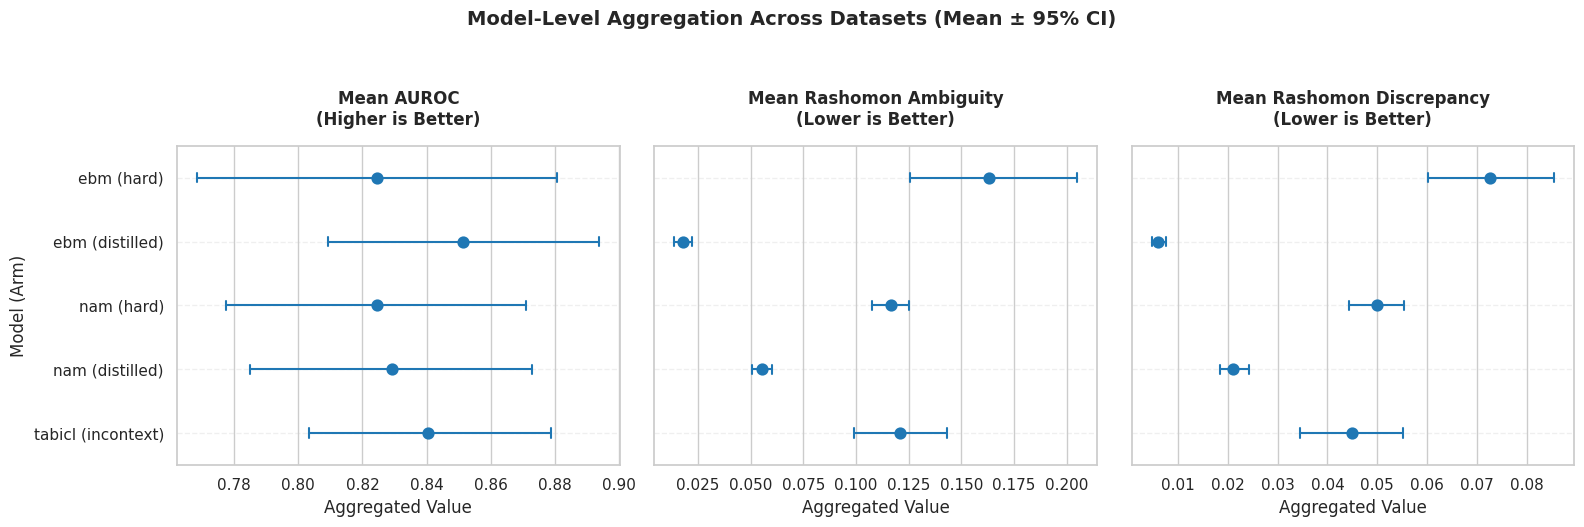

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
# df = pd.read_csv("your_results.csv")

# Create a unified identifier for model and arm to keep them distinct
df["model_variant"] = df["model"] + " (" + df["arm"] + ")"

# ---------------------------------------------------------
# 1. Compute Average Ranks Across Datasets
# ---------------------------------------------------------
# Rank within each dataset. 
# AUROC: Higher is better (ascending=False)
# Ambiguity/Discrepancy: Lower is better (ascending=True)
df["auroc_rank"] = df.groupby("dataset")["mean_auroc_point"].rank(ascending=False)
df["ambiguity_rank"] = df.groupby("dataset")["rashomon_ambiguity"].rank(ascending=True)
df["discrepancy_rank"] = df.groupby("dataset")["rashomon_discrepancy"].rank(ascending=True)

# Calculate the mean rank for each model variant
rank_summary = df.groupby("model_variant")[
    ["auroc_rank", "ambiguity_rank", "discrepancy_rank"]
].mean().reset_index()

# Rename columns for a clean printout
rank_summary.columns = ["Model Variant", "Avg Rank: AUROC", "Avg Rank: Ambiguity", "Avg Rank: Discrepancy"]

print("Average Ranks Across Datasets (Lower Rank = Better Performance/Lower Multiplicity):")
print(rank_summary.to_string(index=False))
print("-" * 60)

# ---------------------------------------------------------
# 2. Plotting the Dot Plot with 95% CIs
# ---------------------------------------------------------
metrics = {
    "mean_auroc_point": "Mean AUROC\n(Higher is Better)",
    "rashomon_ambiguity": "Mean Rashomon Ambiguity\n(Lower is Better)",
    "rashomon_discrepancy": "Mean Rashomon Discrepancy\n(Lower is Better)"
}

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, (metric, title) in zip(axes, metrics.items()):
    # pointplot automatically bootstraps 95% CIs across the aggregated samples (datasets)
    sns.pointplot(
        data=df,
        x=metric,
        y="model_variant",
        errorbar=('ci', 95),
        linestyle="none",      # Removes connecting lines to make it a true dot plot
        marker="o",
        color="#1f77b4",
        capsize=0.15,          # Adds caps to the error bars
        err_kws={'linewidth': 1.5},
        ax=ax
    )
    
    ax.set_title(title, fontweight="bold", pad=15)
    ax.set_ylabel("Model (Arm)" if ax == axes[0] else "")
    ax.set_xlabel("Aggregated Value")
    ax.grid(axis="y", linestyle="--", alpha=0.3) # Horizontal guide lines

plt.suptitle("Model-Level Aggregation Across Datasets (Mean ± 95% CI)", y=1.05, fontsize=14, fontweight="bold")
plt.tight_layout()

plt.savefig("model_aggregate_dotplot.pdf", bbox_inches="tight")
plt.savefig("model_aggregate_dotplot.png", dpi=300, bbox_inches="tight")
plt.show()

Average Ranks Across Datasets:
     Model Variant  Avg Rank: AUROC  Avg Rank: Ambiguity  Avg Rank: Discrepancy
   ebm (distilled)              4.0             3.000000               3.000000
        ebm (hard)             15.2            19.666667              20.277778
   nam (distilled)             16.3             8.500000               8.000000
        nam (hard)             17.8            16.100000              15.700000
tabicl (incontext)             11.7            17.200000              17.550000
------------------------------------------------------------


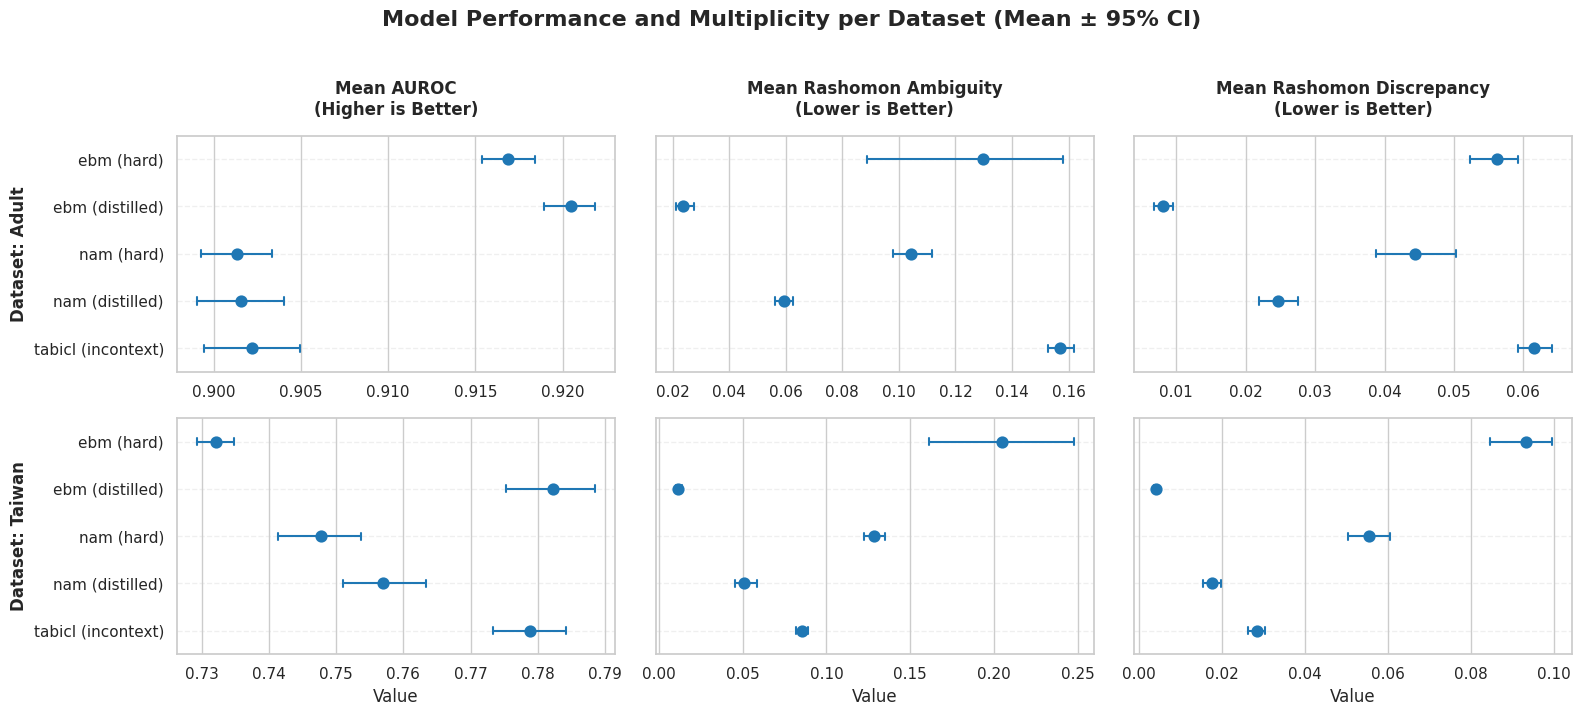

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
# df = pd.read_csv("your_results.csv")

# Create a unified identifier for model and arm to keep them distinct
df["model_variant"] = df["model"] + " (" + df["arm"] + ")"

# ---------------------------------------------------------
# 1. Compute Average Ranks Across Datasets
# ---------------------------------------------------------
df["auroc_rank"] = df.groupby("dataset")["mean_auroc_point"].rank(ascending=False)
df["ambiguity_rank"] = df.groupby("dataset")["rashomon_ambiguity"].rank(ascending=True)
df["discrepancy_rank"] = df.groupby("dataset")["rashomon_discrepancy"].rank(ascending=True)

rank_summary = df.groupby("model_variant")[
    ["auroc_rank", "ambiguity_rank", "discrepancy_rank"]
].mean().reset_index()

rank_summary.columns = ["Model Variant", "Avg Rank: AUROC", "Avg Rank: Ambiguity", "Avg Rank: Discrepancy"]

print("Average Ranks Across Datasets:")
print(rank_summary.to_string(index=False))
print("-" * 60)

# ---------------------------------------------------------
# 2. Plotting the Dot Plot Grid (Per Dataset Only)
# ---------------------------------------------------------
metrics = {
    "mean_auroc_point": "Mean AUROC\n(Higher is Better)",
    "rashomon_ambiguity": "Mean Rashomon Ambiguity\n(Lower is Better)",
    "rashomon_discrepancy": "Mean Rashomon Discrepancy\n(Lower is Better)"
}

datasets = df["dataset"].unique()
num_rows = len(datasets)

sns.set_theme(style="whitegrid")

# Dynamically scale the figure height based on the number of datasets
fig, axes = plt.subplots(
    num_rows, 3, 
    figsize=(16, max(4, 3.5 * num_rows)), 
    sharey=True
)

# Ensure axes is always a 2D array even if there is only 1 row
if num_rows == 1:
    axes = [axes]

for row_idx, dataset_name in enumerate(datasets):
    # Filter data for the specific dataset
    plot_data = df[df["dataset"] == dataset_name]
    
    for col_idx, (metric, title) in enumerate(metrics.items()):
        ax = axes[row_idx][col_idx]

        sns.pointplot(
            data=plot_data,
            x=metric,
            y="model_variant",
            errorbar=('ci', 95),
            linestyle="none",
            marker="o",
            color="#1f77b4", # Standard blue
            capsize=0.15,
            err_kws={'linewidth': 1.5},
            ax=ax
        )
        
        # Formatting: Top row gets the metric titles
        if row_idx == 0:
            ax.set_title(title, fontweight="bold", pad=15)
        else:
            ax.set_title("")

        # Formatting: First column gets the row labels (Dataset names)
        if col_idx == 0:
            ax.set_ylabel(f"Dataset: {dataset_name.capitalize()}", fontweight="bold", fontsize=12)
        else:
            ax.set_ylabel("")

        # Formatting: Bottom row gets the x-axis labels
        if row_idx == num_rows - 1:
            ax.set_xlabel("Value")
        else:
            ax.set_xlabel("")

        ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.suptitle("Model Performance and Multiplicity per Dataset (Mean ± 95% CI)", y=1.02, fontsize=16, fontweight="bold")
plt.tight_layout()

plt.savefig("model_per_dataset_dotplot.pdf", bbox_inches="tight")
plt.savefig("model_per_dataset_dotplot.png", dpi=300, bbox_inches="tight")
plt.show()

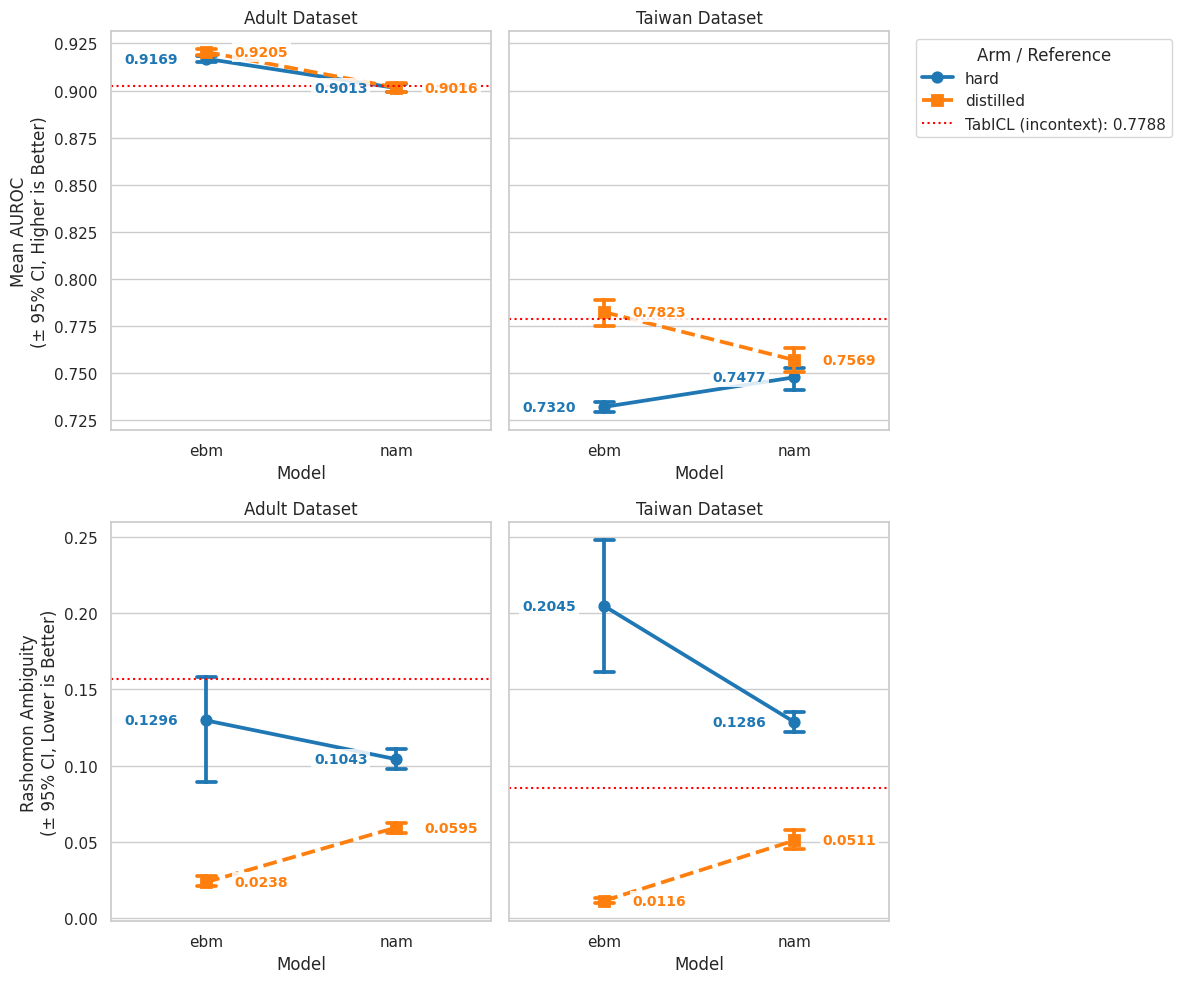

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define metrics to plot and explicitly state the variance (95% CI)
metrics = {
    "mean_auroc_point": "Mean AUROC\n(± 95% CI, Higher is Better)",
    "rashomon_ambiguity": "Rashomon Ambiguity\n(± 95% CI, Lower is Better)"
}

datasets = df["dataset"].unique()

fig, axes = plt.subplots(len(metrics), len(datasets), figsize=(12, 10), sharey="row")

for i, (metric, ylabel) in enumerate(metrics.items()):
    for j, dataset in enumerate(datasets):
        ax = axes[i, j]
        
        # Subset for current dataset
        ds_data = df[df["dataset"] == dataset]
        
        # Extract TabICL baseline for reference line
        tabicl_val = ds_data[ds_data["model"] == "tabicl"][metric].mean()
        
        # Filter out TabICL for the main categorical plot
        student_data = ds_data[ds_data["model"] != "tabicl"]
        
        # Plot EBM and NAM comparing Hard vs Distilled
        sns.pointplot(
            data=student_data,
            x="model",
            y=metric,
            hue="arm",
            dodge=False,
            markers=["o", "s"],
            linestyles=["-", "--"],
            palette={"hard": "#1f77b4", "distilled": "#ff7f0e"},
            errorbar=('ci', 95),  
            capsize=0.1,          
            ax=ax,
            zorder=2 # Ensure points/lines draw over the grid but under text
        )
        
        # --- FIX: Offset text further and add a background box ---
        model_order = student_data["model"].unique()
        model_to_x = {model: idx for idx, model in enumerate(model_order)}
        
        agg_data = student_data.groupby(["model", "arm"])[metric].mean().reset_index()
        
        for _, row in agg_data.iterrows():
            model = row["model"]
            arm = row["arm"]
            val = row[metric]
            
            # Increased offset from 0.1 to 0.15 for more breathing room
            x_pos = model_to_x[model]
            x_offset = -0.15 if arm == "hard" else 0.15
            ha = 'right' if arm == "hard" else 'left'
            color = "#1f77b4" if arm == "hard" else "#ff7f0e"
            
            ax.text(
                x=x_pos + x_offset, 
                y=val, 
                s=f"{val:.4f}",
                color=color,
                va='center', 
                ha=ha,
                fontweight='bold',
                fontsize=10,
                zorder=3, # Force text to draw on top of everything
                # This bbox creates a white mask behind the text to hide overlapping lines
                bbox=dict(facecolor='white', alpha=0.85, edgecolor='none', pad=2) 
            )
        # ---------------------------------------------------------
        
        # Add TabICL reference line
        if pd.notna(tabicl_val):
            ax.axhline(tabicl_val, color="red", linestyle=":", label=f"TabICL (incontext): {tabicl_val:.4f}")
            
        ax.set_title(f"{dataset.capitalize()} Dataset")
        ax.set_ylabel(ylabel if j == 0 else "")
        ax.set_xlabel("Model")
        
        # Handle legends
        if i == 0 and j == len(datasets) - 1:
            ax.legend(title="Arm / Reference", bbox_to_anchor=(1.05, 1), loc='upper left')
        else:
            if ax.get_legend() is not None:
                ax.get_legend().remove()

plt.tight_layout()
plt.savefig("distilled_vs_hard_comparison_with_values.pdf", bbox_inches="tight")
plt.show()

In [16]:
import numpy as np
import pandas as pd
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer

warnings.filterwarnings("ignore")


# Remove completely empty columns
df = df.dropna(axis=1, how="all")

# Remove accidental index column
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

print(f"Dataset shape: {df.shape}")

print("\nTipos das colunas:")
print(df.dtypes)


# ==========================================
# 2. RENOMEAR COLUNAS
# ==========================================

column_mapping = {
    "ID": "ID",
    "X1": "LIMIT_BAL",
    "X2": "SEX",
    "X3": "EDUCATION",
    "X4": "MARRIAGE",
    "X5": "AGE",
    "X6": "PAY_0",
    "X7": "PAY_2",
    "X8": "PAY_3",
    "X9": "PAY_4",
    "X10": "PAY_5",
    "X11": "PAY_6",
    "X12": "BILL_AMT1",
    "X13": "BILL_AMT2",
    "X14": "BILL_AMT3",
    "X15": "BILL_AMT4",
    "X16": "BILL_AMT5",
    "X17": "BILL_AMT6",
    "X18": "PAY_AMT1",
    "X19": "PAY_AMT2",
    "X20": "PAY_AMT3",
    "X21": "PAY_AMT4",
    "X22": "PAY_AMT5",
    "X23": "PAY_AMT6",
    "Y": "default_payment",
}

# Verificar colunas disponíveis
missing_columns = [
    col for col in column_mapping
    if col not in df.columns
]

if missing_columns:
    print(
        "\nWARNING: As seguintes colunas esperadas "
        f"não foram encontradas: {missing_columns}"
    )

existing_cols = [
    col for col in column_mapping
    if col in df.columns
]

df = df[existing_cols]
df = df.rename(columns=column_mapping)

print("\nColunas após renomeação:")
print(df.columns.tolist())


# ==========================================
# 3. DEFINIR TIPOS DAS VARIÁVEIS
# ==========================================

# Variáveis contínuas
numeric_cols = [
    "LIMIT_BAL",
    "AGE",
    "BILL_AMT1",
    "BILL_AMT2",
    "BILL_AMT3",
    "BILL_AMT4",
    "BILL_AMT5",
    "BILL_AMT6",
    "PAY_AMT1",
    "PAY_AMT2",
    "PAY_AMT3",
    "PAY_AMT4",
    "PAY_AMT5",
    "PAY_AMT6",
]

# Variáveis categóricas
categorical_cols = [
    "SEX",
    "EDUCATION",
    "MARRIAGE",
]

# Variáveis ordinais
ordinal_cols = [
    "PAY_0",
    "PAY_2",
    "PAY_3",
    "PAY_4",
    "PAY_5",
    "PAY_6",
]


# ==========================================
# 4. CONVERSÃO PARA NUMÉRICO
# ==========================================

print("\nConvertendo variáveis numéricas...")

for col in numeric_cols + ordinal_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(
            df[col],
            errors="coerce"
        )

# Categóricas como strings
for col in categorical_cols:
    if col in df.columns:
        df[col] = (
            df[col]
            .astype("string")
            .str.strip()
        )


# Target
if "default_payment" not in df.columns:
    raise ValueError(
        "Coluna 'default_payment' não encontrada."
    )

df["default_payment"] = pd.to_numeric(
    df["default_payment"],
    errors="coerce"
)

print("\nTipos após conversão:")
print(df.dtypes)


# ==========================================
# 5. VERIFICAR VALORES INVÁLIDOS / MISSING
# ==========================================

print("\nValores missing antes do tratamento:")
print(df.isnull().sum())


# ==========================================
# 6. TRATAMENTO DE MISSING
# ==========================================

# Variáveis numéricas + ordinais
for col in numeric_cols + ordinal_cols:

    if col in df.columns:

        median = df[col].median()

        df[col] = df[col].fillna(median)


# Variáveis categóricas
for col in categorical_cols:

    if col in df.columns:

        mode = df[col].mode()

        if len(mode) > 0:
            fill_value = mode.iloc[0]
        else:
            fill_value = "Unknown"

        df[col] = df[col].fillna(fill_value)


# Target: NÃO imputar
df = df.dropna(
    subset=["default_payment"]
)


# Garantir target inteiro
df["default_payment"] = (
    df["default_payment"]
    .astype(int)
)


print("\nValores missing após tratamento:")
print(df.isnull().sum())


# ==========================================
# 7. VALIDAR TARGET
# ==========================================

unique_target = sorted(
    df["default_payment"].unique()
)

print(
    f"\nValores únicos do target: "
    f"{unique_target}"
)

if not set(unique_target).issubset({0, 1}):
    raise ValueError(
        "O target deve conter somente 0 e 1."
    )


# ==========================================
# 8. SEPARAR FEATURES E TARGET
# ==========================================

feature_cols = [
    col
    for col in df.columns
    if col not in [
        "ID",
        "default_payment"
    ]
]

X = df[feature_cols].copy()
y = df["default_payment"].copy()


print("\nFeatures:")
print(feature_cols)

print("\nTarget distribution:")
print(y.value_counts())

print("\nTarget proportion:")
print(y.value_counts(normalize=True))


# ==========================================
# 9. SPLIT TREINO / VALIDAÇÃO / TESTE
# ==========================================

# 75% development / 25% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# 75% train / 25% validation dentro
# do conjunto de desenvolvimento
#
# Resultado final:
# Train = 56.25%
# Validation = 18.75%
# Test = 25%
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    random_state=42,
    stratify=y_temp
)


print("\n" + "=" * 50)
print("DATA SPLIT")
print("=" * 50)

print(
    f"Train: {X_train.shape}, "
    f"Val: {X_val.shape}, "
    f"Test: {X_test.shape}"
)

print(
    f"\nTarget rate - "
    f"Train: {y_train.mean():.4f}, "
    f"Val: {y_val.mean():.4f}, "
    f"Test: {y_test.mean():.4f}"
)


# ==========================================
# 10. IDENTIFICAR COLUNAS
# ==========================================

existing_cat_cols = [
    col
    for col in categorical_cols
    if col in X_train.columns
]

existing_ordinal_cols = [
    col
    for col in ordinal_cols
    if col in X_train.columns
]

existing_num_cols = [
    col
    for col in numeric_cols
    if col in X_train.columns
]

print("\nColunas categóricas:")
print(existing_cat_cols)

print("\nColunas ordinais:")
print(existing_ordinal_cols)

print("\nColunas numéricas:")
print(existing_num_cols)


# ==========================================
# 11. PRÉ-PROCESSAMENTO
# ==========================================

# Categorical:
#   OrdinalEncoder
#
# Ordinal:
#   StandardScaler
#
# Continuous:
#   StandardScaler
#
# ID:
#   removido anteriormente

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OrdinalEncoder(
                handle_unknown="use_encoded_value",
                unknown_value=-1
            ),
            existing_cat_cols
        ),
        (
            "ordinal",
            StandardScaler(),
            existing_ordinal_cols
        ),
        (
            "num",
            StandardScaler(),
            existing_num_cols
        ),
    ],
    remainder="drop"
)


# ==========================================
# 12. FIT SOMENTE NO TRAIN
# ==========================================

print("\nAplicando pré-processamento...")

X_train = preprocessor.fit_transform(
    X_train
)

X_val = preprocessor.transform(
    X_val
)

X_test = preprocessor.transform(
    X_test
)



Dataset shape: (30001, 24)

Tipos das colunas:
X1     str
X2     str
X3     str
X4     str
X5     str
X6     str
X7     str
X8     str
X9     str
X10    str
X11    str
X12    str
X13    str
X14    str
X15    str
X16    str
X17    str
X18    str
X19    str
X20    str
X21    str
X22    str
X23    str
Y      str
dtype: object


Colunas após renomeação:
['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default_payment']

Convertendo variáveis numéricas...

Tipos após conversão:
LIMIT_BAL          float64
SEX                 string
EDUCATION           string
MARRIAGE            string
AGE                float64
PAY_0              float64
PAY_2              float64
PAY_3              float64
PAY_4              float64
PAY_5              float64
PAY_6              float64
BILL_AMT1       

In [17]:
from sklearn.utils import shuffle
from interpret.glassbox import ExplainableBoostingClassifier
from sklearn.metrics import brier_score_loss, roc_auc_score
from sklearn.model_selection import KFold
import numpy as np

clfs = []
kf = KFold(n_splits=2, shuffle=True, random_state=34)

for fold, (train_index, val_index) in enumerate(kf.split(X_train)):
    print(f"Fold {fold+1}")
    X_ = X_train[train_index]
    y_ = y_train.iloc[train_index].copy()
    
    # Treina o modelo (EBM)
    clf = ExplainableBoostingClassifier(interactions=0, max_rounds=100)
    clf.fit(X_, y_)
    clfs.append(clf)
    
    # Avalia no conjunto de validação limpo (y_val)
    y_pred_proba = clf.predict_proba(X_val)[:, 1]
    
    brier = brier_score_loss(y_val, y_pred_proba)
    auc = roc_auc_score(y_val, y_pred_proba)
    
    print(f"Brier Score Loss do Modelo {fold+1} no Validation Set: {brier:.4f}")
    print(f"AUC do Modelo {fold+1} no Validation Set: {auc:.4f}")

Fold 1
Brier Score Loss do Modelo 1 no Validation Set: 0.1354
AUC do Modelo 1 no Validation Set: 0.7794
Fold 2
Brier Score Loss do Modelo 2 no Validation Set: 0.1358
AUC do Modelo 2 no Validation Set: 0.7780


In [18]:
import numpy as np
from interpret.glassbox import ExplainableBoostingClassifier
from sklearn.metrics import brier_score_loss
from sklearn.model_selection import KFold

from recgam.utils import calculate_disagreement, calculate_ambiguity, calculate_global_explanation_multiplicity

# ==========================================
# Configurações do Experimento
# ==========================================
n_seeds = 10 
kf = KFold(n_splits=2, shuffle=True, random_state=34)

metrics_results = []

for fold, (train_index, val_index) in enumerate(kf.split(X_train)):
    print(f"\n{'='*30}\nFold {fold+1}\n{'='*30}")
    
    # CORREÇÃO: Usar iloc para acessar as linhas do DataFrame/array
    X_ = X_train[train_index] if isinstance(X_train, np.ndarray) else X_train.iloc[train_index]
    y_ = y_train[train_index].copy() if isinstance(y_train, np.ndarray) else y_train.iloc[train_index].copy()
    
    preds_proba_list = []
    preds_class_list = []
    importances_list = []
    brier_scores = []
    
    # --- LOOP DE MULTIPLICIDADE (EQUAÇÃO 8) ---
    for seed in range(n_seeds):
        clf = ExplainableBoostingClassifier(interactions='2x', max_rounds=100, random_state=seed)
        clf.fit(X_, y_)
        
        # CORREÇÃO: Garantir que X_val seja acessado corretamente
        X_val_fold = X_val if isinstance(X_val, np.ndarray) else X_val.values
        
        y_prob = clf.predict_proba(X_val_fold)[:, 1]
        y_pred = clf.predict(X_val_fold)
        
        preds_proba_list.append(y_prob)
        preds_class_list.append(y_pred)
        
        global_expl = clf.explain_global()
        importances_list.append(global_expl.data()['scores'])
        
        brier_scores.append(brier_score_loss(y_val, y_prob))
        
    # ==========================================
    # Chamada das Funções de Multiplicidade
    # ==========================================
    
    preds_proba = np.column_stack(preds_proba_list)
    preds_class = np.column_stack(preds_class_list)
    importances_matrix = np.array(importances_list)
    
    # Utiliza as funções definidas anteriormente no seu ambiente
    fold_disagreement = calculate_disagreement(preds_class)[0]
    fold_ambiguity = calculate_ambiguity(preds_proba)[0].mean()
    fold_spearman = calculate_global_explanation_multiplicity(importances_matrix)['mean_spearman_correlation']
    
    print(f"Brier Score Loss (Média das Seeds): {np.mean(brier_scores):.4f}")
    print(f"Disagreement: {fold_disagreement:.4%}")
    print(f"Ambiguity (Var): {fold_ambiguity:.4f}")
    print(f"Explanation Correlation (Spearman): {fold_spearman:.4f}")
    
    metrics_results.append({
        'fold': fold + 1,
        'disagreement': fold_disagreement,
        'ambiguity': fold_ambiguity,
        'explanation_corr': fold_spearman
    })

# ==========================================
# Resumo Final do Experimento
# ==========================================
print("\n" + "="*30)
print("RESULTADOS GLOBAIS (Média entre os Folds)")
print("="*30)
print(f"Disagreement Médio Global: {np.mean([r['disagreement'] for r in metrics_results]):.4%}")
print(f"Ambiguity Média Global: {np.mean([r['ambiguity'] for r in metrics_results]):.4f}")
print(f"Explanation Rank Correlation Médio: {np.mean([r['explanation_corr'] for r in metrics_results]):.4f}")


Fold 1
Brier Score Loss (Média das Seeds): 0.1325
Disagreement: 0.4156%
Ambiguity (Var): 0.0001
Explanation Correlation (Spearman): 0.8454

Fold 2
Brier Score Loss (Média das Seeds): 0.1336
Disagreement: 0.3911%
Ambiguity (Var): 0.0001
Explanation Correlation (Spearman): 0.8689

RESULTADOS GLOBAIS (Média entre os Folds)
Disagreement Médio Global: 0.4034%
Ambiguity Média Global: 0.0001
Explanation Rank Correlation Médio: 0.8572


In [ ]:
import numpy as np
from interpret.glassbox import ExplainableBoostingClassifier
from sklearn.metrics import brier_score_loss
from sklearn.model_selection import KFold, train_test_split
from sklearn.datasets import make_classification

from recgam.utils import calculate_disagreement, calculate_ambiguity, calculate_global_explanation_multiplicity

# ==========================================
# 1. GERAR DATASET SINTÉTICO
# ==========================================

# Gerar dados com alta complexidade
X, y = make_classification(
    n_samples=10000,
    n_features=20,
    n_informative=10,
    n_redundant=5,
    n_repeated=3,
    n_classes=2,
    n_clusters_per_class=6,
    flip_y=0.05,
    random_state=42
)

# Split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

# ==========================================
# 2. EXPERIMENTO - CORRIGIDO
# ==========================================

n_seeds = 10
kf = KFold(n_splits=2, shuffle=True, random_state=34)

metrics_results = []

for fold, (train_index, val_index) in enumerate(kf.split(X_train)):
    print(f"\n{'='*30}\nFold {fold+1}\n{'='*30}")
    
    X_ = X_train[train_index]
    y_ = y_train[train_index].copy()
    
    preds_proba_list = []
    preds_class_list = []
    importances_list = []
    brier_scores = []
    
    # Armazenar o número de features para padronização
    n_features = X_.shape[1]
    
    for seed in range(n_seeds):
        # Usar diferentes interações para criar multiplicidade
        if seed < 3:
            interactions = 0
        elif seed < 6:
            interactions = 10
        else:
            interactions = '3x'
            
        clf = ExplainableBoostingClassifier(
            interactions=interactions, 
            max_rounds=100, 
            random_state=seed
        )
        clf.fit(X_, y_)
        
        y_prob = clf.predict_proba(X_val)[:, 1]
        y_pred = clf.predict(X_val)
        
        preds_proba_list.append(y_prob)
        preds_class_list.append(y_pred)
        
        # ==========================================
        # CORREÇÃO: Garantir que todas as importâncias tenham o mesmo tamanho
        # ==========================================
        global_expl = clf.explain_global()
        scores = global_expl.data()['scores']
        
        # Se o tamanho for diferente, preencher com zeros
        if len(scores) < n_features:
            # Adicionar zeros no final
            scores = np.pad(scores, (0, n_features - len(scores)), 'constant')
        elif len(scores) > n_features:
            # Truncar para o número de features
            scores = scores[:n_features]
            
        importances_list.append(scores)
        brier_scores.append(brier_score_loss(y_val, y_prob))
    
    preds_proba = np.column_stack(preds_proba_list)
    preds_class = np.column_stack(preds_class_list)
    importances_matrix = np.array(importances_list)  # Agora funciona!
    
    fold_disagreement = calculate_disagreement(preds_class)[0]
    fold_ambiguity = calculate_ambiguity(preds_proba)[0].mean()
    fold_spearman = calculate_global_explanation_multiplicity(importances_matrix)['mean_spearman_correlation']
    
    print(f"Brier Score Loss: {np.mean(brier_scores):.4f}")
    print(f"Disagreement: {fold_disagreement:.4%}")
    print(f"Ambiguity: {fold_ambiguity:.4f}")
    print(f"Correlation: {fold_spearman:.4f}")
    
    metrics_results.append({
        'fold': fold + 1,
        'disagreement': fold_disagreement,
        'ambiguity': fold_ambiguity,
        'explanation_corr': fold_spearman
    })

print("\n" + "="*30)
print("RESULTADOS GLOBAIS")
print("="*30)
print(f"Disagreement Médio Global: {np.mean([r['disagreement'] for r in metrics_results]):.4%}")
print(f"Ambiguity Média Global: {np.mean([r['ambiguity'] for r in metrics_results]):.4f}")
print(f"Correlation Média Global: {np.mean([r['explanation_corr'] for r in metrics_results]):.4f}")

Train: (7000, 20), Val: (1500, 20), Test: (1500, 20)

Fold 1
Brier Score Loss: 0.1741
Disagreement: 9.8933%
Ambiguity: 0.0070
Correlation: 0.9842

Fold 2
Brier Score Loss: 0.1728
Disagreement: 10.3052%
Ambiguity: 0.0070
Correlation: 0.9938

RESULTADOS GLOBAIS
Disagreement Médio Global: 10.0993%
Ambiguity Média Global: 0.0070
Correlation Média Global: 0.9890


In [11]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss, roc_auc_score, accuracy_score
from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_classification
from sklearn.utils import shuffle

from recgam.utils import calculate_disagreement, calculate_ambiguity, calculate_global_explanation_multiplicity

# ==========================================
# 1. GERAR DATASET SINTÉTICO
# ==========================================

print("Gerando dataset sintético...")

# Gerar dados com alta complexidade
X, y = make_classification(
    n_samples=10000,
    n_features=20,
    n_informative=10,
    n_redundant=5,
    n_repeated=3,
    n_classes=2,
    n_clusters_per_class=6,  # Múltiplos clusters = mais multiplicidade
    flip_y=0.05,
    random_state=42
)

# Split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

# Normalizar dados (importante para Logistic Regression)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print(f"Dataset shape: {X.shape}")
print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"Target rate - Train: {np.mean(y_train):.4f}, Val: {np.mean(y_val):.4f}, Test: {np.mean(y_test):.4f}")

# ==========================================
# 2. EXPERIMENTO COM LOGISTIC REGRESSION
# ==========================================

print("\n" + "="*50)
print("EXPERIMENTO COM LOGISTIC REGRESSION")
print("="*50)

n_seeds = 30
kf = KFold(n_splits=2, shuffle=True, random_state=34)

metrics_results = []

for fold, (train_index, val_index) in enumerate(kf.split(X_train)):
    print(f"\n{'='*30}\nFold {fold+1}\n{'='*30}")
    
    X_ = X_train[train_index]
    y_ = y_train[train_index].copy()
    
    preds_proba_list = []
    preds_class_list = []
    coefs_list = []  # Para Logistic Regression, usamos coeficientes em vez de importâncias
    brier_scores = []
    
    # Número de features
    n_features = X_.shape[1]
    
    for seed in range(n_seeds):
        # ==========================================
        # CRIAR MULTIPLICIDADE COM DIFERENTES CONFIGURAÇÕES
        # ==========================================
        
        # Opção 1: Diferentes regularizações
        if seed % 3 == 0:
            C = 0.01  # Regularização forte
            penalty = 'l2'
        elif seed % 3 == 1:
            C = 1.0   # Regularização padrão
            penalty = 'l2'
        else:
            C = 100.0  # Regularização fraca
            penalty = 'l1'  # L1 para esparsidade
        
        # Opção 2: Diferentes solvers
        solvers = ['lbfgs', 'liblinear', 'saga']
        solver = solvers[seed % len(solvers)]
        
        # Opção 3: Diferentes pesos de classe (para criar mais multiplicidade)
        if seed < 3:
            class_weight = None
        elif seed < 6:
            class_weight = 'balanced'
        else:
            class_weight = {0: 1.0, 1: 1.5}  # Peso diferente para classe positiva
        
        # Criar modelo
        clf = LogisticRegression(
            C=C,
            penalty=penalty,
            solver=solver if penalty == 'l1' else 'lbfgs',  # L1 só funciona com 'saga' ou 'liblinear'
            class_weight=class_weight,
            max_iter=1000,
            random_state=seed
        )
        
        # Ajustar para L1 com solver apropriado
        if penalty == 'l1' and solver not in ['liblinear', 'saga']:
            solver = 'liblinear'
            clf = LogisticRegression(
                C=C,
                penalty=penalty,
                solver=solver,
                class_weight=class_weight,
                max_iter=1000,
                random_state=seed
            )
        
        clf.fit(X_, y_)
        
        # Predições
        y_prob = clf.predict_proba(X_val)[:, 1]
        y_pred = clf.predict(X_val)
        
        preds_proba_list.append(y_prob)
        preds_class_list.append(y_pred)
        
        # Coeficientes (importâncias para Logistic Regression)
        coefs = clf.coef_[0]
        
        # Padronizar tamanho
        if len(coefs) < n_features:
            coefs = np.pad(coefs, (0, n_features - len(coefs)), 'constant')
        elif len(coefs) > n_features:
            coefs = coefs[:n_features]
        
        coefs_list.append(coefs)
        
        brier_scores.append(brier_score_loss(y_val, y_prob))
    
    # ==========================================
    # Cálculo das Métricas de Multiplicidade
    # ==========================================
    
    preds_proba = np.column_stack(preds_proba_list)
    preds_class = np.column_stack(preds_class_list)
    coefs_matrix = np.array(coefs_list)  # Matriz de coeficientes
    
    # Calcular métricas
    fold_disagreement = calculate_disagreement(preds_class)[0]
    fold_ambiguity = calculate_ambiguity(preds_proba)[0].mean()
    
    # Correlação de Spearman entre coeficientes
    from scipy.stats import spearmanr
    spearman_corrs = [spearmanr(coefs_matrix[i], coefs_matrix[j])[0] 
                      for i, j in zip(range(n_seeds), range(1, n_seeds)) if i < j]
    # Para todos os pares
    from itertools import combinations
    spearman_corrs = [spearmanr(coefs_matrix[i], coefs_matrix[j])[0] 
                      for i, j in combinations(range(n_seeds), 2)]
    fold_spearman = np.mean(spearman_corrs) if spearman_corrs else 1.0
    
    print(f"Brier Score Loss (Média das Seeds): {np.mean(brier_scores):.4f}")
    print(f"Disagreement: {fold_disagreement:.4%}")
    print(f"Ambiguity (Var): {fold_ambiguity:.4f}")
    print(f"Explanation Correlation (Spearman): {fold_spearman:.4f}")
    
    # Métricas adicionais
    print(f"AUC Médio: {np.mean([roc_auc_score(y_val, p) for p in preds_proba_list]):.4f}")
    print(f"Accuracy Médio: {np.mean([accuracy_score(y_val, p_class) for p_class in preds_class_list]):.4f}")
    
    metrics_results.append({
        'fold': fold + 1,
        'disagreement': fold_disagreement,
        'ambiguity': fold_ambiguity,
        'explanation_corr': fold_spearman,
        'brier_mean': np.mean(brier_scores)
    })

# ==========================================
# RESULTADOS FINAIS
# ==========================================
print("\n" + "="*30)
print("RESULTADOS GLOBAIS (Média entre os Folds)")
print("="*30)
print(f"Brier Score Médio Global: {np.mean([r['brier_mean'] for r in metrics_results]):.4f}")
print(f"Disagreement Médio Global: {np.mean([r['disagreement'] for r in metrics_results]):.4%}")
print(f"Ambiguity Média Global: {np.mean([r['ambiguity'] for r in metrics_results]):.4f}")
print(f"Explanation Rank Correlation Médio: {np.mean([r['explanation_corr'] for r in metrics_results]):.4f}")

# ==========================================
# AVALIAÇÃO NO TEST SET
# ==========================================
print("\n" + "="*30)
print("AVALIAÇÃO NO TEST SET")
print("="*30)

# Treinar modelo final com todos os dados de treino
final_clf = LogisticRegression(C=1.0, penalty='l2', solver='lbfgs', max_iter=1000, random_state=42)
final_clf.fit(X_train, y_train)

y_test_proba = final_clf.predict_proba(X_test)[:, 1]
y_test_pred = final_clf.predict(X_test)

test_brier = brier_score_loss(y_test, y_test_proba)
test_auc = roc_auc_score(y_test, y_test_proba)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"Brier Score Loss (Test Set): {test_brier:.4f}")
print(f"AUC (Test Set): {test_auc:.4f}")
print(f"Accuracy (Test Set): {test_acc:.4f}")

Gerando dataset sintético...
Dataset shape: (10000, 20)
Train: (7000, 20), Val: (1500, 20), Test: (1500, 20)
Target rate - Train: 0.5009, Val: 0.5007, Test: 0.5007

EXPERIMENTO COM LOGISTIC REGRESSION

Fold 1
Brier Score Loss (Média das Seeds): 0.2214
Disagreement: 5.8434%
Ambiguity (Var): 0.0013
Explanation Correlation (Spearman): 0.9844
AUC Médio: 0.7164
Accuracy Médio: 0.6543

Fold 2
Brier Score Loss (Média das Seeds): 0.2204
Disagreement: 6.1726%
Ambiguity (Var): 0.0012
Explanation Correlation (Spearman): 0.9647
AUC Médio: 0.7160
Accuracy Médio: 0.6610

RESULTADOS GLOBAIS (Média entre os Folds)
Brier Score Médio Global: 0.2209
Disagreement Médio Global: 6.0080%
Ambiguity Média Global: 0.0013
Explanation Rank Correlation Médio: 0.9745

AVALIAÇÃO NO TEST SET
Brier Score Loss (Test Set): 0.2080
AUC (Test Set): 0.7422
Accuracy (Test Set): 0.6980


In [20]:
import numpy as np
from pygam import LinearGAM, s
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold, train_test_split
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. GERAR DATASET
# ==========================================

X, y = make_classification(
    n_samples=2000,
    n_features=5,
    n_informative=3,
    n_classes=2,
    n_clusters_per_class=3,
    flip_y=0.05,
    random_state=42
)

# Converter y para contínuo (regressão)
y = y.astype(float)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

# ==========================================
# 2. EXPERIMENTO COM LINEAR GAM
# ==========================================

n_seeds = 10
kf = KFold(n_splits=2, shuffle=True, random_state=34)

# Criar termos
terms = s(0)
for i in range(1, X_train.shape[1]):
    terms = terms + s(i)

metrics_results = []

for fold, (train_index, val_index) in enumerate(kf.split(X_train)):
    print(f"\n{'='*30}\nFold {fold+1}\n{'='*30}")
    
    X_ = X_train[train_index]
    y_ = y_train[train_index].copy()
    
    preds_list = []
    mse_scores = []
    
    for seed in range(n_seeds):
        try:
            n_splines = [6, 8, 10, 12][seed % 4]
            lam = [0.01, 0.1, 1.0, 10.0][seed % 4]
            
            clf = LinearGAM(
                terms=terms,
                n_splines=n_splines,
                lam=lam,
                max_iter=200,
                verbose=False
            )
            
            clf.fit(X_, y_)
            y_pred = clf.predict(X_val)
            
            preds_list.append(y_pred)
            mse_scores.append(mean_squared_error(y_val, y_pred))
            
        except:
            continue
    
    if len(preds_list) == 0:
        print("Nenhum modelo treinado!")
        continue
    
    preds_matrix = np.column_stack(preds_list)
    
    # Disagreement para regressão
    disagreements = []
    for i in range(len(preds_list)):
        for j in range(i+1, len(preds_list)):
            diff = np.abs(preds_matrix[:, i] - preds_matrix[:, j])
            disagreements.append(np.mean(diff > 0.1))  # threshold 0.1
    
    fold_disagreement = np.mean(disagreements)
    fold_ambiguity = np.mean(np.var(preds_matrix, axis=1))
    
    print(f"MSE: {np.mean(mse_scores):.4f}")
    print(f"Disagreement: {fold_disagreement:.4%}")
    print(f"Ambiguity: {fold_ambiguity:.4f}")
    print(f"Models: {len(preds_list)}/{n_seeds}")
    
    metrics_results.append({
        'fold': fold + 1,
        'disagreement': fold_disagreement,
        'ambiguity': fold_ambiguity
    })

print("\n" + "="*30)
print("RESULTADOS GLOBAIS")
print("="*30)
print(f"Disagreement Médio: {np.mean([r['disagreement'] for r in metrics_results]):.4%}")
print(f"Ambiguity Média: {np.mean([r['ambiguity'] for r in metrics_results]):.4f}")

Train: (1400, 5), Val: (300, 5), Test: (300, 5)

Fold 1
MSE: 0.1074
Disagreement: 2.0222%
Ambiguity: 0.0006
Models: 10/10

Fold 2
MSE: 0.1140
Disagreement: 1.3630%
Ambiguity: 0.0005
Models: 10/10

RESULTADOS GLOBAIS
Disagreement Médio: 1.6926%
Ambiguity Média: 0.0005


In [4]:
from recgam.reclogit import ReconcileClassifierLogit
# from recgam.utils import estimate_expected_jacobian

rclr_clf = ReconcileClassifierLogit(clfs[0], clfs[1], alpha=0.01, epsilon=0.05)
rclr_clf.fit(X_val, y_val, use_expected_jacobian=True)

           Model  Brier Score       AUC    ACC
0    M1 Original     0.188717  0.736524  0.710
1  M1 Reconciled     0.176061  0.772080  0.715
2    M2 Original     0.177984  0.773903  0.775
3  M2 Reconciled     0.178478  0.766838  0.730


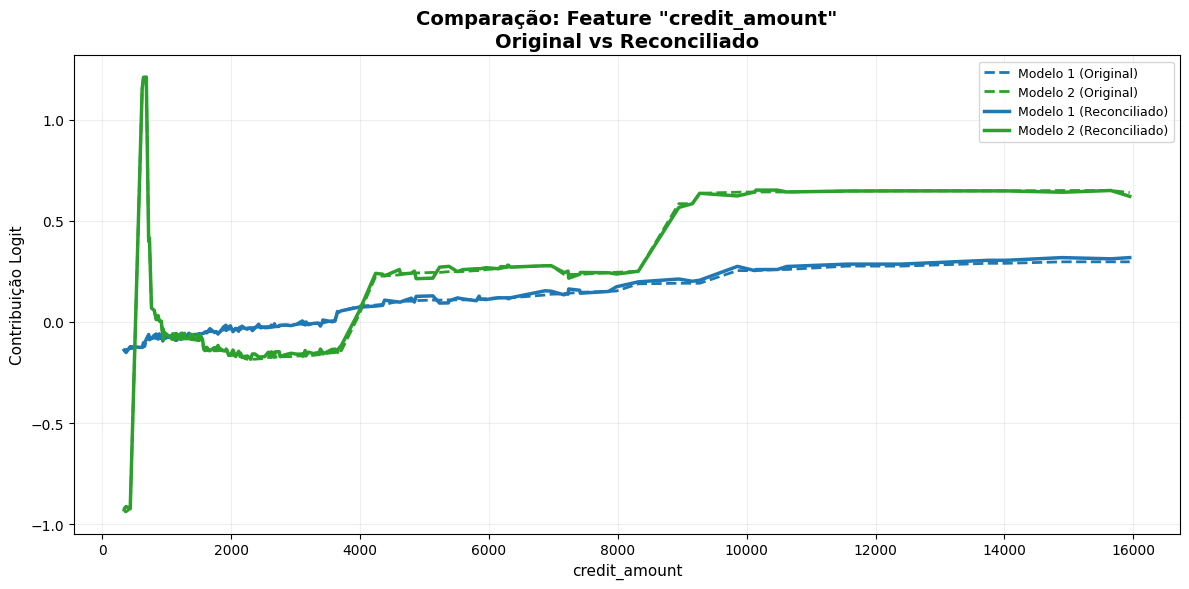

In [13]:
from recgam.plots import ReconciliationVisualizer

# No seu script principal:
viz = ReconciliationVisualizer(
    reconciler=rclr_clf, 
    X=X_test, 
    y=y_test, 
    feature_names=X_df.columns.tolist()
)

# 1. Ver métricas
print(viz.get_metrics_summary())

# # 2. Ver a nuvem de consenso
viz.plot_feature_comparison(6)  # Exemplo para a primeira feature

# # 3. Ver todas as shapes de uma vez (o mais informativo para o EBM)
# viz.plot_all_shapes(cols=4)

# viz.plot_disagreement_cloud()

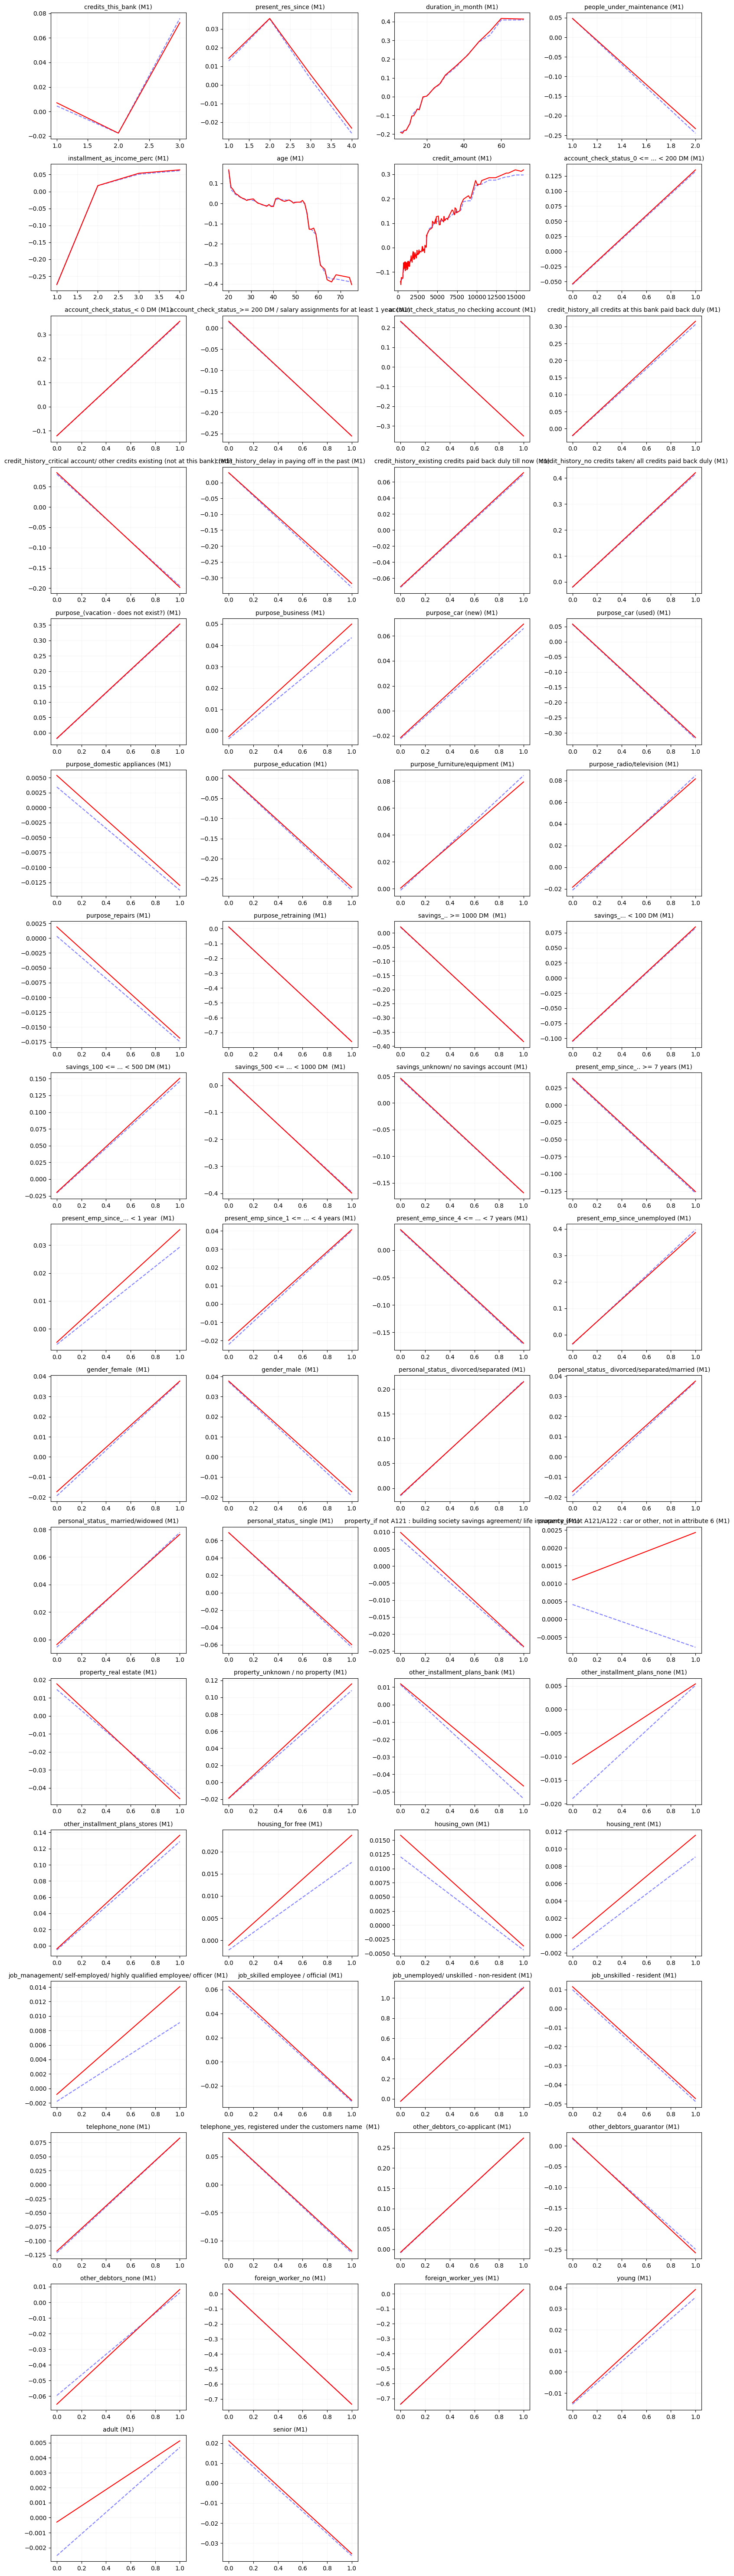

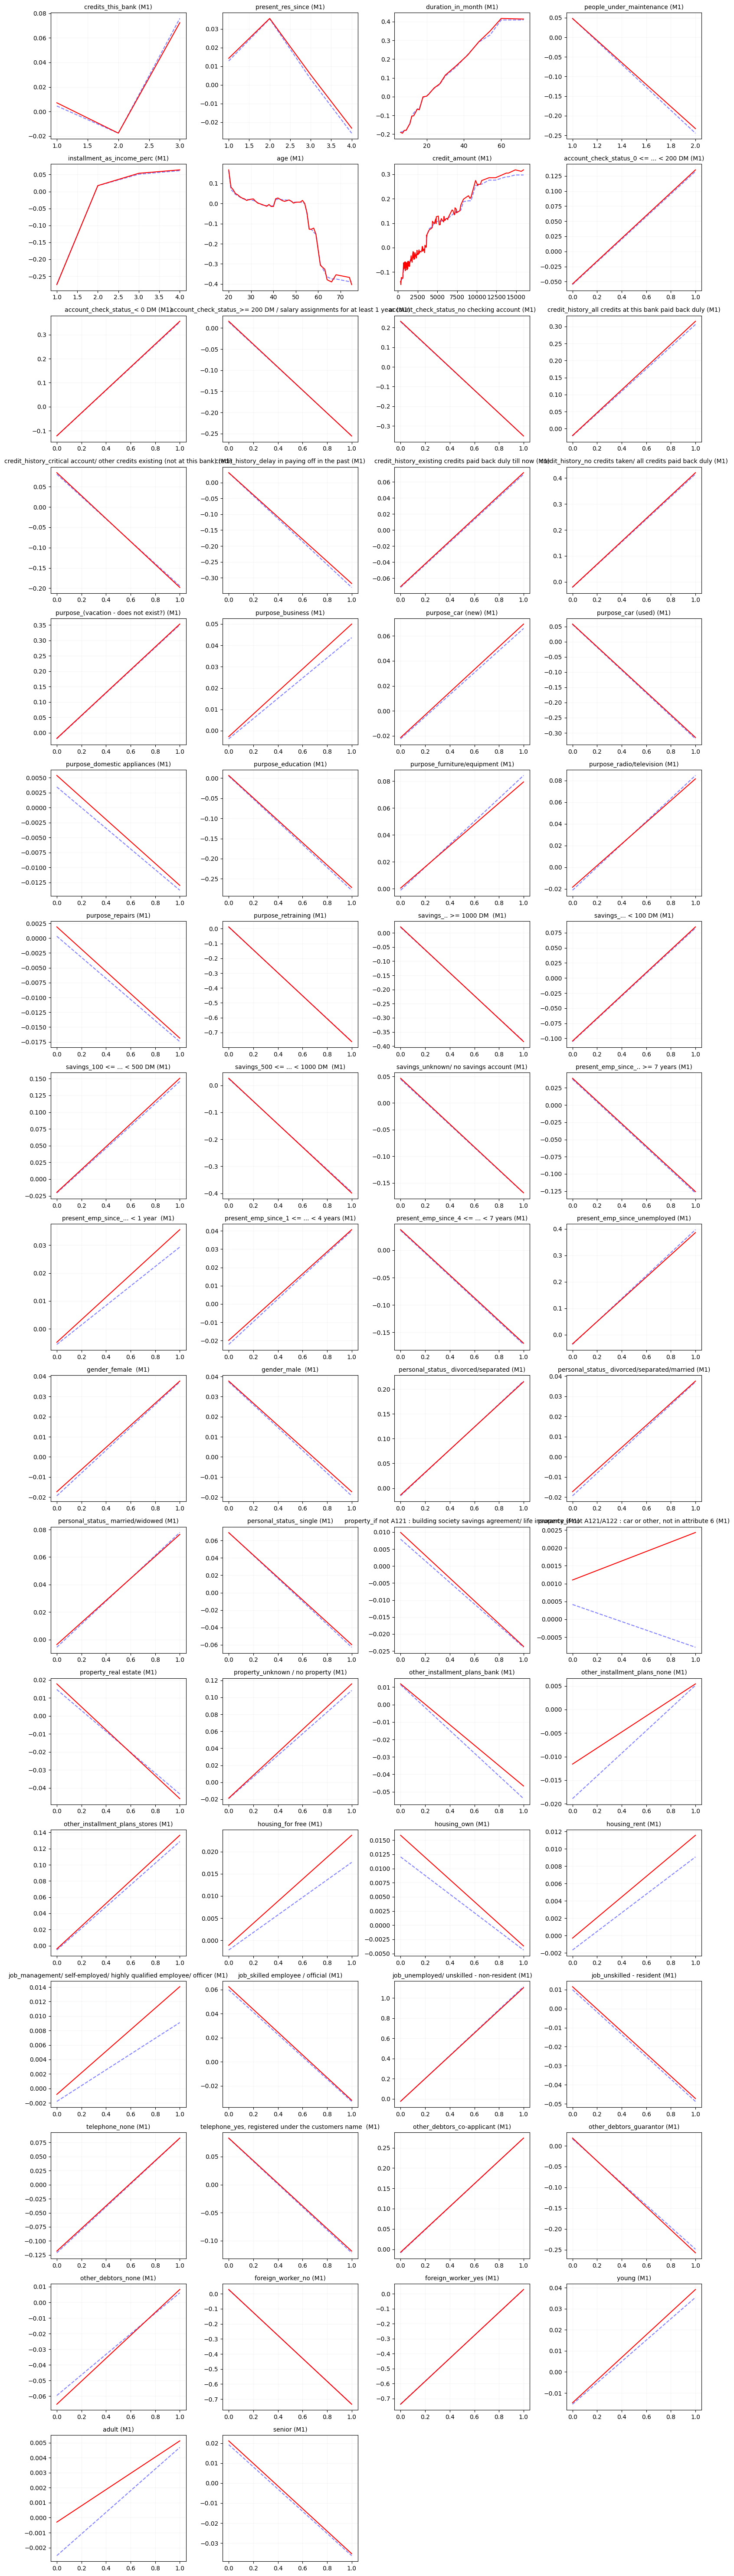

In [6]:
viz.plot_all_shapes(cols=4)
